Device: cuda
Scanning dataset folders...
  train  →  site: 769  no_site: 1764  total: 2533
  validation  →  site: 177  no_site: 407  total: 584
  test  →  site: 150  no_site: 350  total: 500
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 188MB/s]



  Training  |  Epochs 30  |  Batch 16  |  cuda
Ep 01/30 | LR: 9.97e-05  ✓ saved
  Train -> Loss: 0.0510 | AUC: 0.6337 | F1: 0.5707 | Prec: 0.5936 | Rec: 0.5495 | Acc: 0.6001
  Valid -> Loss: 0.0469 | AUC: 0.5847 | F1: 0.4528 | Prec: 0.3887 | Rec: 0.5424 | Acc: 0.6027
Ep 02/30 | LR: 9.89e-05
  Train -> Loss: 0.0474 | AUC: 0.6790 | F1: 0.6385 | Prec: 0.6345 | Rec: 0.6425 | Acc: 0.6313
  Valid -> Loss: 0.0619 | AUC: 0.5764 | F1: 0.4539 | Prec: 0.3252 | Rec: 0.7514 | Acc: 0.4521
Ep 03/30 | LR: 9.76e-05
  Train -> Loss: 0.0460 | AUC: 0.6860 | F1: 0.6341 | Prec: 0.6333 | Rec: 0.6348 | Acc: 0.6270
  Valid -> Loss: 0.0495 | AUC: 0.5750 | F1: 0.4100 | Prec: 0.3435 | Rec: 0.5085 | Acc: 0.5565
Ep 04/30 | LR: 9.57e-05  ✓ saved
  Train -> Loss: 0.0438 | AUC: 0.7059 | F1: 0.6569 | Prec: 0.6482 | Rec: 0.6659 | Acc: 0.6566
  Valid -> Loss: 0.0446 | AUC: 0.6305 | F1: 0.4475 | Prec: 0.3755 | Rec: 0.5537 | Acc: 0.5856
Ep 05/30 | LR: 9.34e-05
  Train -> Loss: 0.0427 | AUC: 0.7147 | F1: 0.6522 | Prec: 0.6

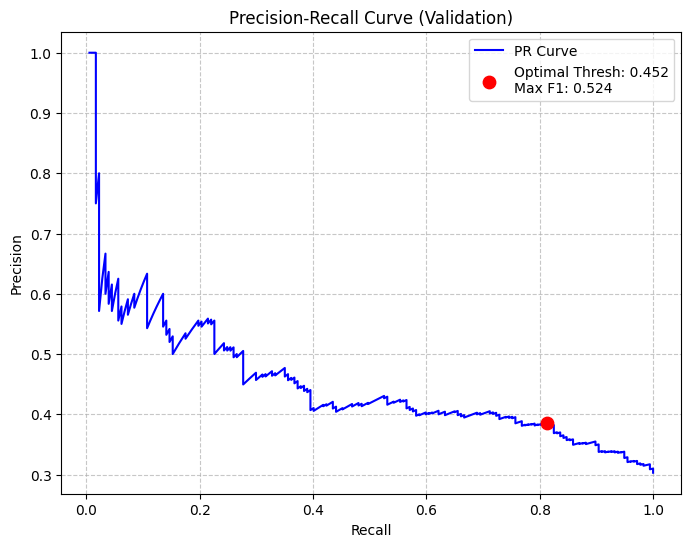


--- Running Inference with Test-Time Augmentation ---
  Running TTA Pass 1/4...
  Running TTA Pass 2/4...
  Running TTA Pass 3/4...
  Running TTA Pass 4/4...

submission_tta.csv saved successfully! 🎉


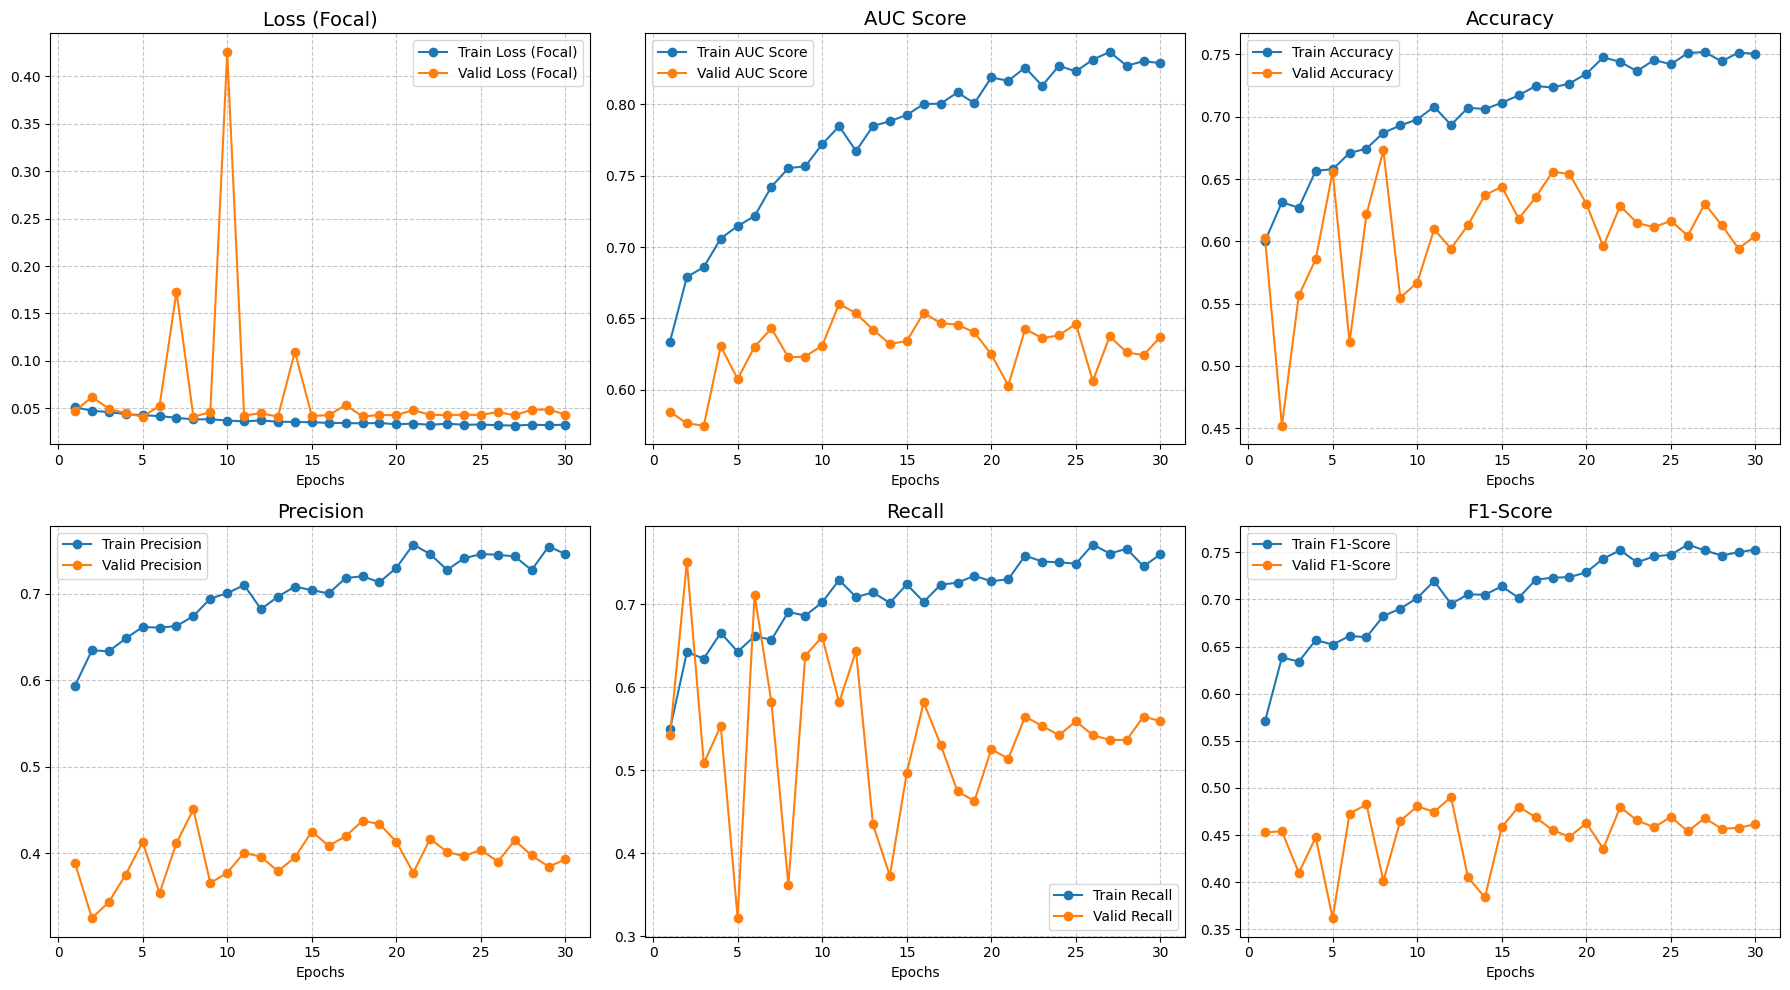

In [1]:
# !pip install -q rasterio  # uncomment if needed
import os, random, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast
import torchvision.models as models
import torchvision.transforms.functional as TF
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, accuracy_score, precision_recall_curve

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

# ══════════════════════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════════════════════
class CFG:
    # ── Actual Kaggle paths from your dataset ─────────────────────────────────
    ROOT          = Path('/kaggle/input/datasets/shreyansdeshpande/2nd-variation/FINALCNNDATA_NEW_01')
    
    TRAIN_SITE    = ROOT / 'train' / 'site'
    TRAIN_NOSITE  = ROOT / 'train' / 'no_site'
    VAL_SITE      = ROOT / 'validation' / 'site'
    VAL_NOSITE    = ROOT / 'validation' / 'no_site'
    
    # Notice the test directory also has subfolders!
    TEST_SITE     = ROOT / 'test' / 'site'
    TEST_NOSITE   = ROOT / 'test' / 'no_site'
    
    OUTPUT_DIR    = Path('/kaggle/working')

    # ── File format ───────────────────────────────────────────────────────────
    IMG_SUFFIX    = '.tif'
    OPTICAL_BANDS = [0, 1, 2, 3]             # R, G, B, NIR
    LIDAR_BANDS   = [4, 5, 6, 7, 8, 9, 10]   # HS0, HS1, HS2, HS3, LRM, slope, SVF

    # ── Model ─────────────────────────────────────────────────────────────────
    NUM_OPTICAL_CH    = 4
    NUM_LIDAR_CH      = 7
    NUM_CLASSES       = 1
    PRETRAINED        = True
    FREEZE_BACKBONES  = True  
    FUSION_HIDDEN_DIM = 512
    DROPOUT           = 0.5   

    # ── Training ──────────────────────────────────────────────────────────────
    IMG_SIZE     = 250
    BATCH_SIZE   = 16
    NUM_EPOCHS   = 30
    LR           = 1e-4
    WEIGHT_DECAY = 1e-4
    SEED         = 42
    NUM_WORKERS  = 2
    USE_AMP      = False

    # ── Scheduler ─────────────────────────────────────────────────────────────
    T_MAX   = NUM_EPOCHS
    ETA_MIN = 1e-6

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CFG.SEED)
CFG.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ══════════════════════════════════════════════════════════════════════════════
# LOSS FUNCTION FOR CLASS IMBALANCE
# ══════════════════════════════════════════════════════════════════════════════
class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce_with_logits = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        bce_loss = self.bce_with_logits(inputs, targets)
        pt = torch.exp(-bce_loss) # prevents nans
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        return focal_loss.mean()

# ══════════════════════════════════════════════════════════════════════════════
# BUILD DATAFRAMES FROM FOLDER STRUCTURE
# ══════════════════════════════════════════════════════════════════════════════
def folder_to_df(site_dir: Path, nosite_dir: Path) -> pd.DataFrame:
    rows = []
    for label, folder in [(1, site_dir), (0, nosite_dir)]:
        files = list(folder.glob(f'*{CFG.IMG_SUFFIX}'))
        if not files:
            print(f"⚠️ WARNING: No files found in {folder}!")
        for f in sorted(files):
            rows.append({'filepath': str(f), 'label': label})
    
    df = pd.DataFrame(rows, columns=['filepath', 'label'])
    
    if len(df) > 0:
        print(f"  {site_dir.parent.name}  →  site: {(df['label']==1).sum()}  "
              f"no_site: {(df['label']==0).sum()}  total: {len(df)}")
    return df

print('Scanning dataset folders...')
train_df = folder_to_df(CFG.TRAIN_SITE,  CFG.TRAIN_NOSITE)
val_df   = folder_to_df(CFG.VAL_SITE,    CFG.VAL_NOSITE)
test_df  = folder_to_df(CFG.TEST_SITE,   CFG.TEST_NOSITE)

if len(train_df) == 0:
    raise FileNotFoundError("Training DataFrame is empty. Check CFG.ROOT path!")

# ══════════════════════════════════════════════════════════════════════════════
# DATASET
# ══════════════════════════════════════════════════════════════════════════════
def load_patch(path: str) -> np.ndarray:
    path = Path(path)
    suffix = path.suffix.lower()
    if suffix == '.npy':
        arr = np.load(path)
    elif suffix == '.npz':
        arr = np.load(path)['data']
    elif suffix in ('.tif', '.tiff'):
        import rasterio
        with rasterio.open(path) as src:
            arr = src.read().astype(np.float32)
    else:
        raise ValueError(f'Unsupported format: {suffix}')
    if arr.ndim == 2:
        arr = arr[np.newaxis]
    elif arr.ndim == 3 and arr.shape[-1] < arr.shape[0]:
        arr = arr.transpose(2, 0, 1)
    return arr.astype(np.float32)

def per_channel_normalize(arr: np.ndarray) -> np.ndarray:
    out = np.empty_like(arr)
    for c in range(arr.shape[0]):
        ch = arr[c]
        out[c] = (ch - ch.mean()) / (ch.std() + 1e-6)
    return out

class ArchSiteDataset(Dataset):
    def __init__(self, df: pd.DataFrame, is_train: bool = True):
        self.df       = df.reset_index(drop=True)
        self.is_train = is_train
        
    def __len__(self): return len(self.df)
    
    def _augment(self, t):
        if random.random() > 0.5: t = TF.hflip(t)
        if random.random() > 0.5: t = TF.vflip(t)
        angle = random.choice([0, 90, 180, 270])
        if angle: t = TF.rotate(t, angle)
        return t
        
    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        t    = torch.from_numpy(per_channel_normalize(load_patch(row['filepath'])))
        t    = TF.resize(t, [CFG.IMG_SIZE, CFG.IMG_SIZE],
                         interpolation=TF.InterpolationMode.BILINEAR, antialias=True)
        if self.is_train:
            t = self._augment(t)
        return (t[CFG.OPTICAL_BANDS],
                t[CFG.LIDAR_BANDS],
                torch.tensor(row['label'], dtype=torch.float32))

class ArchSiteTestDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.df = df.reset_index(drop=True)
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        t    = torch.from_numpy(per_channel_normalize(load_patch(row['filepath'])))
        t    = TF.resize(t, [CFG.IMG_SIZE, CFG.IMG_SIZE],
                         interpolation=TF.InterpolationMode.BILINEAR, antialias=True)
        return t[CFG.OPTICAL_BANDS], t[CFG.LIDAR_BANDS], Path(row['filepath']).name

# ══════════════════════════════════════════════════════════════════════════════
# MODEL
# ══════════════════════════════════════════════════════════════════════════════
class SingleStreamEncoder(nn.Module):
    def __init__(self, in_channels: int, pretrained: bool = True):
        super().__init__()
        weights  = models.EfficientNet_B0_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = models.efficientnet_b0(weights=weights)
        old_conv = backbone.features[0][0]
        new_conv = nn.Conv2d(
            in_channels, old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=old_conv.bias is not None,
        )
        if pretrained:
            with torch.no_grad():
                mean_w = old_conv.weight.mean(dim=1, keepdim=True)
                new_conv.weight.copy_(mean_w.repeat(1, in_channels, 1, 1))
        
        backbone.features[0][0] = new_conv
        self.features     = backbone.features
        self.pool         = backbone.avgpool
        self.out_features = backbone.classifier[1].in_features

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return torch.flatten(x, 1)

class DualStreamEfficientNet(nn.Module):
    def __init__(self, num_optical_channels=4, num_lidar_channels=7, num_classes=1,
                 pretrained=True, freeze_backbones=True, fusion_hidden_dim=512, dropout=0.5):
        super().__init__()
        self.optical_encoder = SingleStreamEncoder(num_optical_channels, pretrained=pretrained)
        self.lidar_encoder   = SingleStreamEncoder(num_lidar_channels,   pretrained=pretrained)
        
        if freeze_backbones:
            for param in self.optical_encoder.features.parameters():
                param.requires_grad = False
            for param in self.lidar_encoder.features.parameters():
                param.requires_grad = False
            
            for param in self.optical_encoder.features[0][0].parameters():
                param.requires_grad = True
            for param in self.lidar_encoder.features[0][0].parameters():
                param.requires_grad = True

        fused_dim = self.optical_encoder.out_features + self.lidar_encoder.out_features
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, fusion_hidden_dim),
            nn.BatchNorm1d(fusion_hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(fusion_hidden_dim, num_classes),
        )

    def forward(self, optical_x, lidar_x):
        fused = torch.cat([self.optical_encoder(optical_x),
                           self.lidar_encoder(lidar_x)], dim=1)
        return self.classifier(fused)

def get_model():
    return DualStreamEfficientNet(
        num_optical_channels=CFG.NUM_OPTICAL_CH,
        num_lidar_channels=CFG.NUM_LIDAR_CH,
        num_classes=CFG.NUM_CLASSES,
        pretrained=CFG.PRETRAINED,
        freeze_backbones=CFG.FREEZE_BACKBONES,
        fusion_hidden_dim=CFG.FUSION_HIDDEN_DIM,
        dropout=CFG.DROPOUT,
    ).to(DEVICE)

# ══════════════════════════════════════════════════════════════════════════════
# TRAINING UTILITIES
# ══════════════════════════════════════════════════════════════════════════════
def train_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss, all_labels, all_preds = 0.0, [], []
    for optical, lidar, labels in loader:
        optical = optical.to(DEVICE, non_blocking=True)
        lidar   = lidar.to(DEVICE, non_blocking=True)
        labels  = labels.to(DEVICE, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=CFG.USE_AMP):
            logits = model(optical, lidar).squeeze(1)
            loss   = criterion(logits, labels)
            
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item() * labels.size(0)
        all_preds.extend(torch.sigmoid(logits).detach().cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
    auc = roc_auc_score(all_labels, all_preds) if len(set(all_labels)) > 1 else 0.0
    
    bin_preds = [1 if p >= 0.5 else 0 for p in all_preds]
    prec = precision_score(all_labels, bin_preds, zero_division=0)
    rec  = recall_score(all_labels, bin_preds, zero_division=0)
    f1   = f1_score(all_labels, bin_preds, zero_division=0)
    acc  = accuracy_score(all_labels, bin_preds)
    
    return total_loss / len(loader.dataset), auc, prec, rec, f1, acc

@torch.no_grad()
def valid_epoch(model, loader, criterion):
    model.eval()
    total_loss, all_labels, all_preds = 0.0, [], []
    for optical, lidar, labels in loader:
        optical = optical.to(DEVICE, non_blocking=True)
        lidar   = lidar.to(DEVICE, non_blocking=True)
        labels  = labels.to(DEVICE, non_blocking=True)
        
        with autocast(enabled=CFG.USE_AMP):
            logits = model(optical, lidar).squeeze(1)
            loss   = criterion(logits, labels)
            
        total_loss += loss.item() * labels.size(0)
        all_preds.extend(torch.sigmoid(logits).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
    auc = roc_auc_score(all_labels, all_preds) if len(set(all_labels)) > 1 else 0.0
    
    bin_preds = [1 if p >= 0.5 else 0 for p in all_preds]
    prec = precision_score(all_labels, bin_preds, zero_division=0)
    rec  = recall_score(all_labels, bin_preds, zero_division=0)
    f1   = f1_score(all_labels, bin_preds, zero_division=0)
    acc  = accuracy_score(all_labels, bin_preds)
    
    return total_loss / len(loader.dataset), auc, prec, rec, f1, acc


# ══════════════════════════════════════════════════════════════════════════════
# MODIFICATION 1: STRATEGIC SAMPLING (WEIGHTED DATALOADER)
# ══════════════════════════════════════════════════════════════════════════════
# Calculate weights to heavily sample the rare "Site" class
class_counts = train_df['label'].value_counts().to_dict()
class_weights = {0: 1.0 / class_counts[0], 1: 1.0 / class_counts[1]}
sample_weights = [class_weights[label] for label in train_df['label']]

# Create the PyTorch Sampler
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(train_df), replacement=True)

# Notice we removed shuffle=True because the sampler takes over shuffling!
trn_loader = DataLoader(ArchSiteDataset(train_df, is_train=True),
                        batch_size=CFG.BATCH_SIZE, sampler=sampler, 
                        num_workers=CFG.NUM_WORKERS, pin_memory=True, drop_last=True)

val_loader = DataLoader(ArchSiteDataset(val_df, is_train=False),
                        batch_size=CFG.BATCH_SIZE * 2, shuffle=False,
                        num_workers=CFG.NUM_WORKERS, pin_memory=True)

# ══════════════════════════════════════════════════════════════════════════════
# TRAIN 
# ══════════════════════════════════════════════════════════════════════════════
model     = get_model()
criterion = BinaryFocalLoss() 
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), 
                        lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.T_MAX, eta_min=CFG.ETA_MIN)
scaler    = GradScaler(enabled=CFG.USE_AMP)
best_auc  = 0.0
ckpt_path = CFG.OUTPUT_DIR / 'efficientnet_b0_best.pth'

print(f'\n{"="*65}')
print(f'  Training  |  Epochs {CFG.NUM_EPOCHS}  |  Batch {CFG.BATCH_SIZE}  |  {DEVICE}')
print(f'{"="*65}')

history = {
    'train_loss': [], 'train_auc': [], 'train_prec': [], 'train_rec': [], 'train_f1': [], 'train_acc': [],
    'val_loss': [], 'val_auc': [], 'val_prec': [], 'val_rec': [], 'val_f1': [], 'val_acc': []
}

for epoch in range(1, CFG.NUM_EPOCHS + 1):
    trn_loss, trn_auc, trn_prec, trn_rec, trn_f1, trn_acc = train_epoch(model, trn_loader, criterion, optimizer, scaler)
    val_loss, val_auc, val_prec, val_rec, val_f1, val_acc = valid_epoch(model, val_loader, criterion)
    scheduler.step()
    
    history['train_loss'].append(trn_loss); history['val_loss'].append(val_loss)
    history['train_auc'].append(trn_auc);   history['val_auc'].append(val_auc)
    history['train_prec'].append(trn_prec); history['val_prec'].append(val_prec)
    history['train_rec'].append(trn_rec);   history['val_rec'].append(val_rec)
    history['train_f1'].append(trn_f1);     history['val_f1'].append(val_f1)
    history['train_acc'].append(trn_acc);   history['val_acc'].append(val_acc)
    
    saved = ''
    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(), ckpt_path)
        saved = '  ✓ saved'
        
    print(f'Ep {epoch:02d}/{CFG.NUM_EPOCHS} | LR: {optimizer.param_groups[0]["lr"]:.2e}{saved}')
    print(f'  Train -> Loss: {trn_loss:.4f} | AUC: {trn_auc:.4f} | F1: {trn_f1:.4f} | Prec: {trn_prec:.4f} | Rec: {trn_rec:.4f} | Acc: {trn_acc:.4f}')
    print(f'  Valid -> Loss: {val_loss:.4f} | AUC: {val_auc:.4f} | F1: {val_f1:.4f} | Prec: {val_prec:.4f} | Rec: {val_rec:.4f} | Acc: {val_acc:.4f}')


# ══════════════════════════════════════════════════════════════════════════════
# MODIFICATION 2: DECISION THRESHOLD TUNING (PR CURVE)
# ══════════════════════════════════════════════════════════════════════════════
@torch.no_grad()
def tune_decision_threshold(model, loader):
    print("\n--- Tuning Decision Threshold on Validation Set ---")
    model.eval()
    all_labels, all_preds = [], []
    for optical, lidar, labels in loader:
        optical = optical.to(DEVICE, non_blocking=True)
        lidar   = lidar.to(DEVICE, non_blocking=True)
        with autocast(enabled=CFG.USE_AMP):
            probs = torch.sigmoid(model(optical, lidar).squeeze(1))
        all_preds.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())
        
    # Calculate Precision and Recall across all possible thresholds
    precisions, recalls, thresholds = precision_recall_curve(all_labels, all_preds)
    
    # Calculate F1 score for each threshold (ignoring the last element to match array lengths)
    f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
    
    # Find the threshold that yields the absolute best F1 score
    best_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    
    print(f"Optimal Probability Threshold: {optimal_threshold:.4f} (Yields F1: {best_f1:.4f})")
    
    # Plot the curve so you can visually verify it
    plt.figure(figsize=(8, 6))
    plt.plot(recalls[:-1], precisions[:-1], color='blue', label='PR Curve')
    plt.scatter(recalls[best_idx], precisions[best_idx], color='red', s=80, zorder=5, 
                label=f'Optimal Thresh: {optimal_threshold:.3f}\nMax F1: {best_f1:.3f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve (Validation)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
    
    return optimal_threshold

# Load best model weights before tuning
inf_model = get_model()
inf_model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
optimal_threshold = tune_decision_threshold(inf_model, val_loader)

# ══════════════════════════════════════════════════════════════════════════════
# MODIFICATION 3: TEST-TIME AUGMENTATION (TTA) INFERENCE
# ══════════════════════════════════════════════════════════════════════════════
@torch.no_grad()
def predict_tta(model, loader, n_tta=4):
    print("\n--- Running Inference with Test-Time Augmentation ---")
    model.eval()
    
    # The 4 variations the model will look at for every single test image
    aug_fns = [lambda t: t, TF.hflip, TF.vflip, lambda t: TF.rotate(t, 90)][:n_tta]
    all_fnames, all_probs = [], None
    
    for i, aug_fn in enumerate(aug_fns):
        print(f"  Running TTA Pass {i+1}/{n_tta}...")
        batch_probs, batch_fnames = [], []
        
        for optical, lidar, fnames in loader:
            # Apply augmentation on the fly to the batched tensors
            optical_aug = torch.stack([aug_fn(x) for x in optical]).to(DEVICE, non_blocking=True)
            lidar_aug   = torch.stack([aug_fn(x) for x in lidar]).to(DEVICE, non_blocking=True)
            
            with autocast(enabled=CFG.USE_AMP):
                probs = torch.sigmoid(model(optical_aug, lidar_aug).squeeze(1))
            
            batch_probs.extend(probs.cpu().numpy())
            
            # We only need to record the file names on the very first pass
            if i == 0:
                batch_fnames.extend(fnames)
                
        if all_probs is None:
            all_probs = np.array(batch_probs)
            all_fnames = batch_fnames
        else:
            all_probs += np.array(batch_probs)
            
    # Average the probabilities across all TTA passes
    all_probs /= len(aug_fns)
    return all_fnames, all_probs.tolist()

test_loader = DataLoader(ArchSiteTestDataset(test_df),
                         batch_size=CFG.BATCH_SIZE * 2, shuffle=False,
                         num_workers=CFG.NUM_WORKERS, pin_memory=True)

if len(test_df) > 0:
    # Run the new TTA prediction function
    fnames, tta_preds = predict_tta(inf_model, test_loader, n_tta=4)
    
    # Save the raw probabilities for AUC scoring
    sub_df = pd.DataFrame({'filename': fnames, 'probability': tta_preds})
    
    # Use the mathematically optimal threshold to generate hard labels (0 or 1)
    sub_df['label'] = (sub_df['probability'] >= optimal_threshold).astype(int)
    
    sub_df.to_csv(CFG.OUTPUT_DIR / 'submission_tta.csv', index=False)
    print('\nsubmission_tta.csv saved successfully! 🎉')
else:
    print('No test files found. Skipping submission generation.')

# ══════════════════════════════════════════════════════════════════════════════
# PLOT FINAL TRAINING HISTORY
# ══════════════════════════════════════════════════════════════════════════════
def plot_full_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    metrics = [
        ('loss', 'Loss (Focal)'), ('auc', 'AUC Score'), ('acc', 'Accuracy'),
        ('prec', 'Precision'), ('rec', 'Recall'), ('f1', 'F1-Score')
    ]
    
    for i, (key, title) in enumerate(metrics):
        ax = axes[i]
        ax.plot(epochs, history[f'train_{key}'], label=f'Train {title}', marker='o')
        ax.plot(epochs, history[f'val_{key}'], label=f'Valid {title}', marker='o')
        ax.set_title(title, fontsize=14)
        ax.set_xlabel('Epochs')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.7)
        
    plt.tight_layout()
    plt.show()

plot_full_history(history)